# 03 — Fit Gaussian Mixture Model

Fit GMM to preprocessed volume with automatic K selection via BIC. Visualize component distributions.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from research_ct.io.volume_saver import Load_From_Numpy
from research_ct.segmentation.gmm_fitter import Gmm_Fitter
from research_ct.visualization.plot_distributions import plot_gmm_components

# Load preprocessed volume
Processed = Load_From_Numpy(
    r"C:\Users\gabri\Documento\Mitacs\research_ct\data\output\processed\preprocessed_volume.npz"
)
Shape = Processed.shape
print(f"Loaded: {Shape}")


[Load_From_Numpy] Loaded: (201, 1828, 2165)
Loaded: (201, 1828, 2165)


## Flatten Data for GMM

GMM operates on 1D intensity values. Each voxel is treated as an independent sample.

In [2]:
Processed = Processed.ravel().reshape(-1, 1)
print(f"Total voxels: {Processed.shape[0]:,}")
print(f"Memory: {Processed.nbytes / 1e9:.2f} GB")

# For very large volumes, sample a subset
if Processed.shape[0] > 5_000_000:
    print("Sampling 5M voxels for faster fitting...")
    Indices = np.random.choice(Processed.shape[0], 5_000_000, replace=False)
    Sampled = Processed[Indices]
else:
    Sampled = Processed
del Indices


Total voxels: 795,481,620
Memory: 6.36 GB
Sampling 5M voxels for faster fitting...


## Fit GMM with BIC Selection

Test K from 2 to 8. BIC penalizes model complexity — the minimum BIC indicates the best trade-off.

In [3]:
Fitter = Gmm_Fitter(
    Min_Components=2,
    Max_Components=8,
    Covariance_Type="full",
)

Fitter.Fit(Sampled, Verbose=True)

  K=2: BIC=3.66e+07, converged=True
  K=3: BIC=4.39e+07, converged=True
  K=4: BIC=3.54e+07, converged=True
  K=5: BIC=3.43e+07, converged=True
  K=6: BIC=3.40e+07, converged=True
  K=7: BIC=3.40e+07, converged=True
  K=8: BIC=3.39e+07, converged=True
[Gmm_Fitter] Selected K=8


## BIC Scores

Plot BIC vs K to visualize the selection.

In [4]:
fig_dir = Path(r"C:\Users\gabri\Documento\Mitacs\research_ct\data\output\figures")
fig_dir.mkdir(exist_ok=True)


fig, ax = plt.subplots(figsize=(8, 5))
K_Range = range(Fitter.Min_Components, Fitter.Max_Components + 1)
ax.plot(K_Range, Fitter.Bic_Scores, 'o-', linewidth=2, markersize=8, color='steelblue')
ax.axvline(Fitter.Num_Components, color='red', linestyle='--', label=f'Selected K={Fitter.Num_Components}')
ax.set_xlabel('Number of Components (K)')
ax.set_ylabel('BIC Score')
ax.set_title('BIC-Based Model Selection')
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

plt.savefig(fig_dir / "BIC-Based Model Selection", dpi=300, bbox_inches="tight")
plt.close()

C:\Users\gabri\AppData\Local\Temp\ipykernel_4432\3940433595.py:14: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


## Component Distributions

Visualize the fitted Gaussian components against the data histogram.

In [5]:
# Use a smaller sample for plotting (faster)
Plot_Sample = Sampled[np.random.choice(len(Sampled), 100_000, replace=False)].ravel()

fig = plot_gmm_components(Plot_Sample, Fitter.Model)
plt.show()

plt.savefig(fig_dir / "GMM Components", dpi=300, bbox_inches="tight")
plt.close()



C:\Users\gabri\AppData\Local\Temp\ipykernel_4432\4226613605.py:5: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


## Material Statistics

Extract means, variances, and weights of each component.

In [6]:
Stats = Fitter.Get_Material_Statistics()

print(f"{'Component':<12} {'Mean':<10} {'Variance':<12} {'Weight':<10}")
print("-" * 50)
num_components = len(Stats["Means"])
for k in range(num_components):
    var = Stats["Variances"][k]
    # If variance is an array (per‑feature), reduce to a scalar (e.g., mean of diagonal)
    if isinstance(var, np.ndarray):
        var_scalar = np.mean(var)  # average variance across features
    else:
        var_scalar = var
    print(f"{k:<12} {Stats['Means'][k]:<10.2f} {var_scalar:<12.2f} {Stats['Weights'][k]:<10.4f}")

Component    Mean       Variance     Weight    
--------------------------------------------------
0            106.69     250.40       0.0340    
1            173.77     16.53        0.2328    
2            13.16      67.81        0.0116    
3            191.31     125.03       0.1351    
4            168.30     0.79         0.5158    
5            232.13     179.65       0.0283    
6            49.12      108.00       0.0110    
7            138.85     49.41        0.0313    


## Assign Labels to Full Volume

Use the fitted model to classify every voxel.

In [20]:
 
    del Probs_mmap

In [21]:
import numpy as np
import gc
import os

def write_npy_streaming(path, shape, dtype, chunk_iter):
    """Write a large .npy file via plain sequential writes — no memmap,
    so Windows never accumulates a large resident mapping."""
    with open(path, "wb") as f:
        np.lib.format.write_array_header_2_0(
            f,
            {
                "descr": np.lib.format.dtype_to_descr(np.dtype(dtype)),
                "fortran_order": False,
                "shape": shape,
            },
        )
        for chunk in chunk_iter:
            f.write(np.ascontiguousarray(chunk, dtype=dtype).tobytes())
            f.flush()
            os.fsync(f.fileno())  # force OS to actually write, not just buffer


def chunk_generator():
    for i in range(Num_Chunks):
        start, end = i * Chunk_Size, min((i + 1) * Chunk_Size, N)
        chunk = Processed[start:end]
        chunk_probs = Fitter.Predict_Probabilities(chunk).astype(np.float32, copy=False)
        yield chunk_probs
        del chunk, chunk_probs
        if (i + 1) % 10 == 0:
            gc.collect()
            print(f"Processed {i+1}/{Num_Chunks} chunks")

output_dir = Path(r"C:\Users\gabri\Documento\Mitacs\research_ct\data\output")
Chunk_Size = 1_000_000
N = len(Processed)
Num_Chunks = int(np.ceil(N / Chunk_Size))
K = Fitter.Num_Components
probs_path = os.path.join(output_dir, "gmm_probabilities.npy")
D, H, W = Shape

write_npy_streaming(probs_path, (D, H, W, K), np.float32, chunk_generator())

Processed 10/796 chunks
Processed 20/796 chunks
Processed 30/796 chunks
Processed 40/796 chunks
Processed 50/796 chunks
Processed 60/796 chunks
Processed 70/796 chunks
Processed 80/796 chunks
Processed 90/796 chunks
Processed 100/796 chunks
Processed 110/796 chunks
Processed 120/796 chunks
Processed 130/796 chunks
Processed 140/796 chunks
Processed 150/796 chunks
Processed 160/796 chunks
Processed 170/796 chunks
Processed 180/796 chunks
Processed 190/796 chunks
Processed 200/796 chunks
Processed 210/796 chunks
Processed 220/796 chunks
Processed 230/796 chunks
Processed 240/796 chunks
Processed 250/796 chunks
Processed 260/796 chunks
Processed 270/796 chunks
Processed 280/796 chunks
Processed 290/796 chunks
Processed 300/796 chunks
Processed 310/796 chunks
Processed 320/796 chunks
Processed 330/796 chunks
Processed 340/796 chunks
Processed 350/796 chunks
Processed 360/796 chunks
Processed 370/796 chunks
Processed 380/796 chunks
Processed 390/796 chunks
Processed 400/796 chunks
Processed

In [18]:
# Process in chunks to avoid memory issues

import os
import gc
import ctypes
import psutil

proc = psutil.Process(os.getpid())
print(proc.memory_info())  # rss = actual resident memory attributable to this process

output_dir = Path(r"C:\Users\gabri\Documento\Mitacs\research_ct\data\output")

D, H, W = Shape

Chunk_Size = 1_000_000
Num_Chunks = int(np.ceil(len(Processed) / Chunk_Size))

# Create two plain .npy files with the final shapes
labels_path = os.path.join(output_dir, "gmm_labels.npy")
probs_path = os.path.join(output_dir, "gmm_probabilities.npy")

# Memory‑map for writing (mode='w+')
# Labels_mmap = np.lib.format.open_memmap(labels_path, mode="w+", dtype=np.uint8, shape=(D, H, W))
Probs_mmap = np.lib.format.open_memmap(
    probs_path, mode="w+", dtype=np.float32, shape=(D, H, W, Fitter.Num_Components)
)


def trim_working_set():
    """Windows only — ask the OS to release cached/mapped pages that
    flush() alone won't reclaim from this process."""
    if os.name == "nt":
        handle = ctypes.windll.kernel32.GetCurrentProcess()
        ctypes.windll.kernel32.SetProcessWorkingSetSize(handle, -1, -1)


for i in range(Num_Chunks):
    Start = i * Chunk_Size
    End = min((i + 1) * Chunk_Size, len(Processed))
    Chunk = Processed[Start:End]
    #Chunk_Labels = Fitter.Predict_Labels(Chunk)
    Chunk_Probs = Fitter.Predict_Probabilities(Chunk)
    #Labels_mmap.flat[Start:End] = Chunk_Labels
    Probs_mmap.reshape(-1, Fitter.Num_Components)[Start:End] = Chunk_Probs

    del Chunk, Chunk_Probs

    #Labels_mmap.flush()
    Probs_mmap.flush()
    gc.collect()
    trim_working_set()

    if (i + 1) % 10 == 0:
        proc = psutil.Process(os.getpid())
        print(proc.memory_info())  # rss = actual resident memory attributable to this process
        print(f"Processed {i+1}/{Num_Chunks} chunks")

# Reshape to volume


# Labels_mmap.flush()
Probs_mmap.flush()
del Labels_mmap, Probs_mmap
gc.collect()

# print(f"Labels saved to {labels_path} with shape {(D, H, W)}")
print(f"Probabilities saved to {probs_path} with shape {(D, H, W, Fitter.Num_Components)}")

pmem(rss=3167850496, vms=7550291968, num_page_faults=485060785, peak_wset=17195630592, wset=3167850496, peak_paged_pool=51748192, paged_pool=476904, peak_nonpaged_pool=1182680, nonpaged_pool=129464, pagefile=7550291968, peak_pagefile=10290225152, private=7550291968)
pmem(rss=3487870976, vms=7600107520, num_page_faults=487703033, peak_wset=17195630592, wset=3487870976, peak_paged_pool=51748192, paged_pool=50194512, peak_nonpaged_pool=1182680, nonpaged_pool=129504, pagefile=7600107520, peak_pagefile=10290225152, private=7600107520)
Processed 10/796 chunks
pmem(rss=3807870976, vms=7600107520, num_page_faults=490345263, peak_wset=17195630592, wset=3807870976, peak_paged_pool=51748192, paged_pool=50194512, peak_nonpaged_pool=1182680, nonpaged_pool=129504, pagefile=7600107520, peak_pagefile=10290225152, private=7600107520)
Processed 20/796 chunks
pmem(rss=4127870976, vms=7600107520, num_page_faults=492987498, peak_wset=17195630592, wset=4127870976, peak_paged_pool=51748192, paged_pool=501945

KeyboardInterrupt: 

## Visualize Segmentation Slices

Inspect how labels map to spatial structure.

In [ ]:
Processed = Load_From_Numpy(
    r"C:\Users\gabri\Documento\Mitacs\research_ct\data\output\processed\preprocessed_volume.npz"
)

# Memory‑map the labels file – this is the key step
Labels = np.load(
    r"C:\Users\gabri\Documento\Mitacs\research_ct\data\output\gmm_labels.npy", mmap_mode="r"
)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for i, z in enumerate([D//4, D//2, 3*D//4]):
    # Original
    axes[0, i].imshow(Processed[z], cmap='gray')
    axes[0, i].set_title(f'Processed — Z={z}')
    axes[0, i].axis('off')
    
    # Labels
    axes[1, i].imshow(Labels[z], cmap='tab10', vmin=0, vmax=Fitter.Num_Components-1)
    axes[1, i].set_title(f'Labels — Z={z}')
    axes[1, i].axis('off')

axes[0, 0].set_ylabel('Intensity', fontsize=12)
axes[1, 0].set_ylabel('Segmentation', fontsize=12)
plt.suptitle('GMM Segmentation Results', fontsize=14)
plt.tight_layout()
plt.show()

ValueError: cannot reshape array of size 5000000 into shape (201,1828,2165)

In [ ]:
del 

[Load_From_Numpy] Loaded: (201, 1828, 2165)


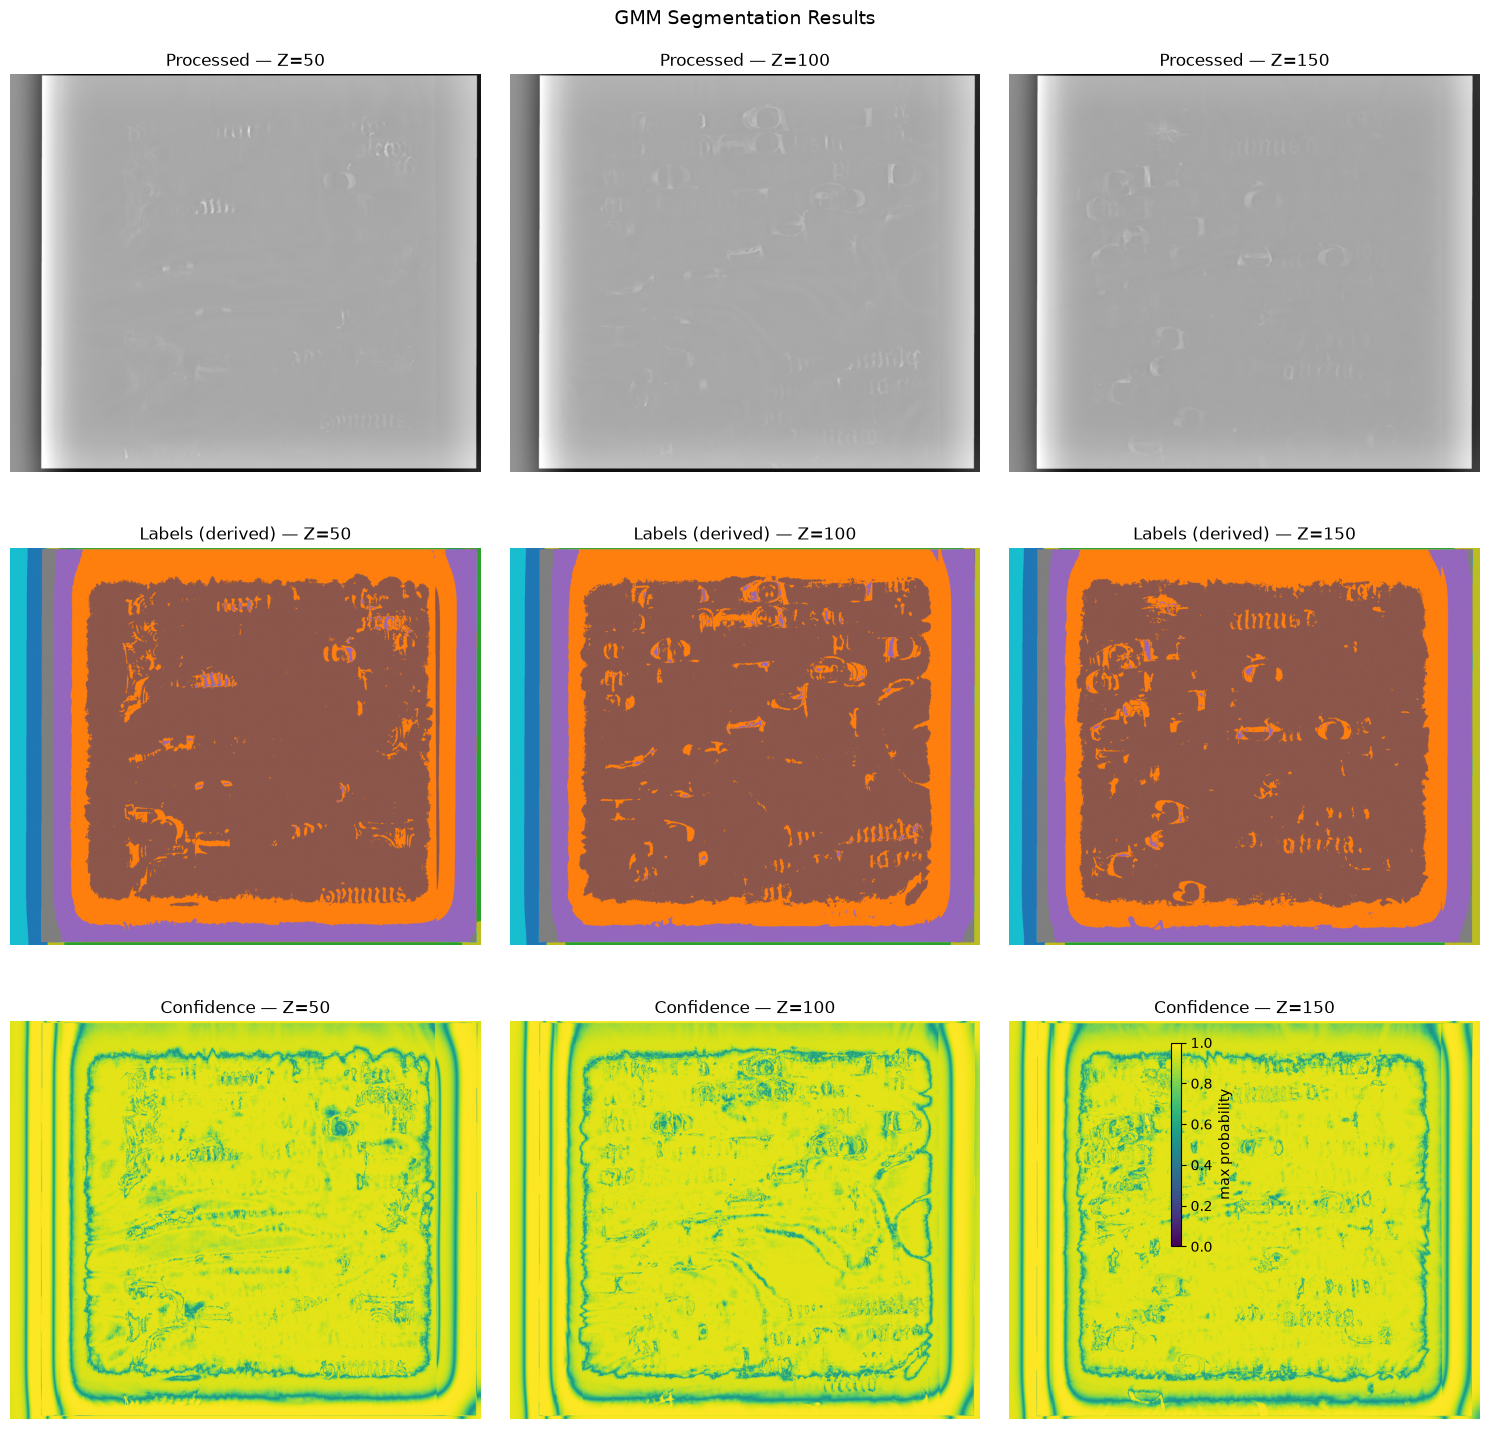

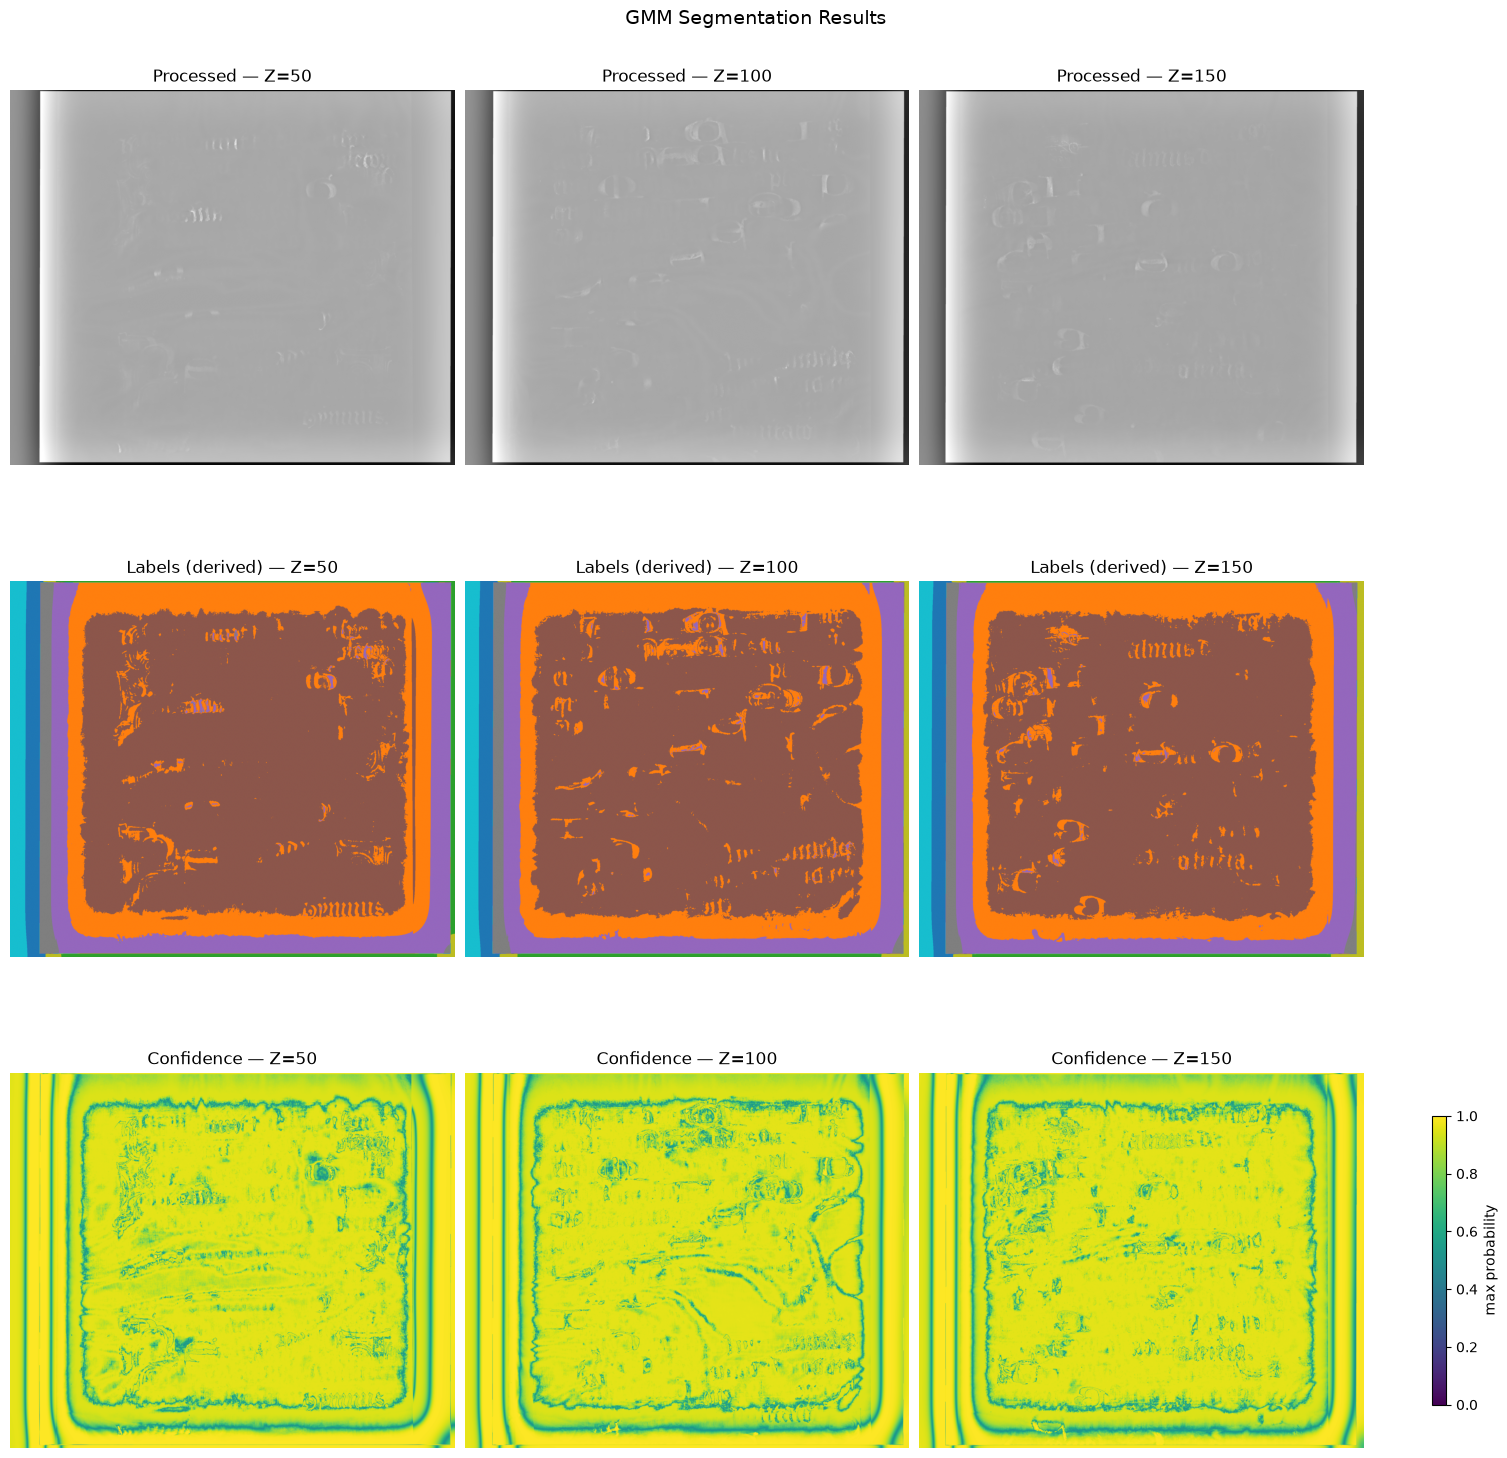

In [29]:
%matplotlib inline
Processed = Load_From_Numpy(
    r"C:\Users\gabri\Documento\Mitacs\research_ct\data\output\processed\preprocessed_volume.npz"
)
Probs = np.load(
    r"C:\Users\gabri\Documento\Mitacs\research_ct\data\output\gmm_probabilities.npy", mmap_mode="r"
)

fig, axes = plt.subplots(3, 3, figsize=(15, 15), constrained_layout=True)

for i, z in enumerate([D // 4, D // 2, 3 * D // 4]):
    prob_slice = Probs[z]  # only this slice read from disk
    label_slice = prob_slice.argmax(axis=-1)
    conf = prob_slice.max(axis=-1)

    axes[0, i].imshow(Processed[z], cmap="gray")
    axes[0, i].set_title(f"Processed — Z={z}")
    axes[0, i].axis("off")

    axes[1, i].imshow(label_slice, cmap="tab10", vmin=0, vmax=Fitter.Num_Components - 1)
    axes[1, i].set_title(f"Labels (derived) — Z={z}")
    axes[1, i].axis("off")

    im = axes[2, i].imshow(conf, cmap="viridis", vmin=0, vmax=1)
    axes[2, i].set_title(f"Confidence — Z={z}")
    axes[2, i].axis("off")

fig.colorbar(im, ax=axes[2, :], shrink=0.6, label="max probability")
plt.suptitle("GMM Segmentation Results", fontsize=14)
plt.show()

## Save Results

Store labels and probabilities for HMRF and visualization.

In [ ]:
from research_ct.io.volume_saver import Save_As_Numpy

Save_As_Numpy(Labels.astype(np.uint8), r"C:\Users\gabri\Documento\Mitacs\research_ct\data\output\gmm_labels.npz")
Save_As_Numpy(Probs.astype(np.float32), r"C:\Users\gabri\Documento\Mitacs\research_ct\data\output\gmm_probabilities.npz")

print("Saved labels and probabilities to ../data/output/figures/")